# 05 · Optimización de contactos: estrategias, sensibilidad y robustez

Convierte las probabilidades del modelo en **a quién contactar, por qué canal y con qué presupuesto**.

- Supuestos: `src/config.py::OPT` (centrales) y `OPT_RANGOS` (rangos). Su porqué: `reports/supuestos_opt.md`.
- Se evalúa en el último mes de validación que **no** es la caja fuerte (t=10) y se calibra solo con meses anteriores.
- Los cálculos pesados los hace `python -m src.sensibilidad` (~6 min). Este notebook lee sus CSV; con `RECALCULAR = True` los rehace.

In [1]:
import os, sys, json
os.chdir('..') if os.path.basename(os.getcwd()) == 'notebooks' else None
sys.path.insert(0, os.getcwd())
import pandas as pd
from IPython.display import display, Markdown
from src import config as C, optimize as O, sensibilidad as S
NOMBRE = 'ens_3'
RECALCULAR = False
if RECALCULAR:
    O.main(NOMBRE); S.main(NOMBRE)
pd.set_option('display.width', 200)
C.OPT

{'presupuesto': 25000.0,
 'canales': {'app': {'costo': 0.3, 'efect': 0.5, 'cap': None},
  'call_center': {'costo': 9.0, 'efect': 1.0, 'cap': 1500},
  'asesor': {'costo': 35.0, 'efect': 1.5, 'cap': 400}},
 'asesor_max_km': 10.0,
 'max_share_riesgo_alto': 0.1,
 'min_dias_desde_interaccion': 7,
 'tasa_margen': 0.015,
 'valor_min': 100.0,
 'valor_max': 1500.0,
 'perdida_esperada': {'low': 0.02, 'medium': 0.06, 'high': 0.15},
 'incrementalidad': 0.5,
 'calibracion': 'isotonica'}

## 1. Las cuatro estrategias con el mismo presupuesto

Se recalcula en vivo en el mes t=10 (≈25 s). *Valor realizado proxy* = y · efectividad · valor − costo con las conversiones observadas.

In [2]:
d, dt, info = O.contexto(NOMBRE)
print(info)
tab, canal = O.comparar(d, C.OPT)
tab

{'t_eval': 10, 't_calib': [8, 9], 'metodo': 'isotonica', 'nombre': 'ens_3'}


,estrategia,contactados,costo,valor_esperado_neto,share_riesgo_alto,n_app,n_call_center,n_asesor,conversiones_reales_contactados,valor_realizado_proxy
0,aleatorio,1686,25000,113693,0.099,66,1220,400,277,124506
1,greedy,1628,25000,207768,0.023,6,1222,400,471,245843
2,greedy_rentab,7443,24999,354867,0.099,5663,1500,280,1334,401035
3,optimo,7020,24967,388855,0.100,5238,1499,283,1275,447275


In [3]:
ev = tab.set_index('estrategia').valor_esperado_neto
display(Markdown(f"- Valor del modelo (greedy − aleatorio): **S/ {ev.greedy - ev.aleatorio:,.0f}**\n"
                 f"- Valor de la optimización (óptimo − greedy): **S/ {ev.optimo - ev.greedy:,.0f}**\n"
                 f"- Óptimo contra greedy por rentabilidad: **S/ {ev.optimo - ev.greedy_rentab:,.0f}**"))

- Valor del modelo (greedy − aleatorio): **S/ 94,075**
- Valor de la optimización (óptimo − greedy): **S/ 181,087**
- Óptimo contra greedy por rentabilidad: **S/ 33,988**

¿Quién recibe qué canal en el óptimo? El asesor se reserva para probabilidad y valor altos; la app cubre la propensión media.

In [4]:
d['canal'] = canal.fillna('sin contacto')
d.groupby('canal').agg(clientes=('p', 'size'), p_media=('p', 'mean'), valor_medio=('valor', 'mean'),
                       tasa_observada=('y', 'mean'), riesgo_alto=('alto', 'mean')).round(3)

,clientes,p_media,valor_medio,tasa_observada,riesgo_alto
canal,,,,,
app,5238,0.150,457.193,0.162,0.129
asesor,283,0.315,617.637,0.389,0.000
call_center,1499,0.186,576.081,0.211,0.017
sin contacto,3380,0.097,382.198,0.104,0.514


## 2. Curva presupuesto → valor

estrategia,aleatorio,greedy,greedy_rentab,optimo,marginal_optimo_por_1000
presupuesto,,,,,
5000,17825,47960,259284,263049,NaN
10000,37718,83272,303086,311329,9656.0
15000,55414,110563,337992,351277,7990.0
25000,113693,207768,354867,388855,3758.0
35000,292440,358809,360296,400981,1213.0
50000,292440,358809,360296,400981,0.0
75000,292440,358809,360296,400981,0.0
100000,292440,358809,360296,400981,0.0


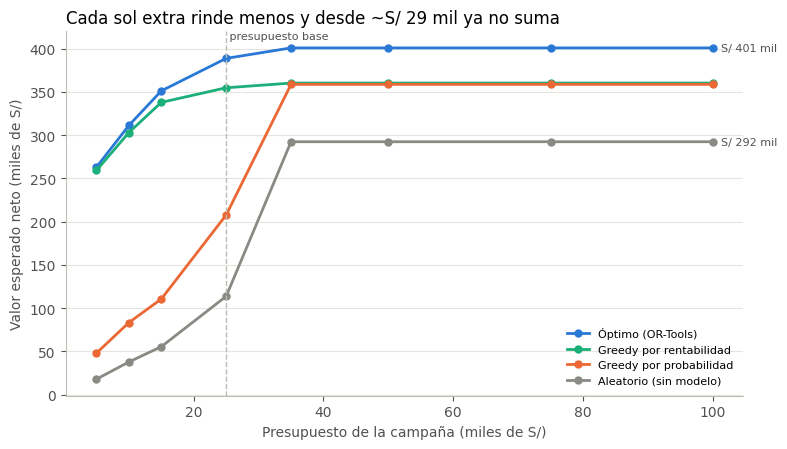

In [5]:
cur = pd.read_csv(C.REPORTS / 'sens_curva.csv')
fig = S.fig_curva(cur, C.REPORTS / 'fig' / 'opt_curva_presupuesto.png')
pv = cur.pivot(index='presupuesto', columns='estrategia', values='valor_esperado_neto')
pv['marginal_optimo_por_1000'] = (pv.optimo.diff() / pv.index.to_series().diff() * 1000).round(0)
pv

## 3. Escenarios

,escenario,valor_esperado_neto,delta_vs_base,contactados,n_app,n_call_center,n_asesor,share_riesgo_alto
3,base,388855,0,7020,5238,1499,283,0.10
7,call_center_-50%,351023,-37832,6453,5303,750,400,0.10
11,riesgo_alto_5%,381932,-6923,6665,4880,1499,286,0.05
15,costo_asesor_x1.5,375141,-13714,6962,5274,1499,189,0.10


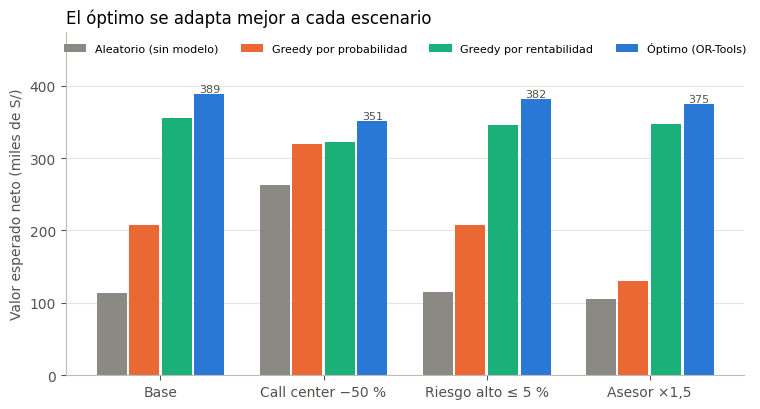

In [6]:
esc = pd.read_csv(C.REPORTS / 'sens_escenarios.csv')
fig = S.fig_escenarios(esc, C.REPORTS / 'fig' / 'opt_escenarios.png')
esc[esc.estrategia == 'optimo'][['escenario', 'valor_esperado_neto', 'delta_vs_base', 'contactados', 'n_app', 'n_call_center', 'n_asesor', 'share_riesgo_alto']]

## 4. Tornado: qué supuesto mueve más el valor

,supuesto,bajo,alto,valor_base,valor_bajo,valor_alto,amplitud
0,incrementalidad,0.30,0.70,389135,223481,554789,331308
1,tasa_margen,0.01,0.02,389135,254150,481074,226924
2,efect_app,0.30,0.70,389135,322445,463904,141459
3,costo_call_center,6.00,15.00,389135,405485,348492,56993
4,cap_call_center,750.00,2000.00,389135,351029,403688,52659
5,presupuesto,15000.00,40000.00,389135,351318,400985,49667
6,efect_asesor,1.20,2.00,389135,373095,415873,42778
7,costo_asesor,25.00,60.00,389135,404719,371573,33146
8,costo_app,0.10,1.00,389135,393363,373615,19748
9,min_dias_desde_interaccion,3.00,30.00,389135,391454,372796,18658


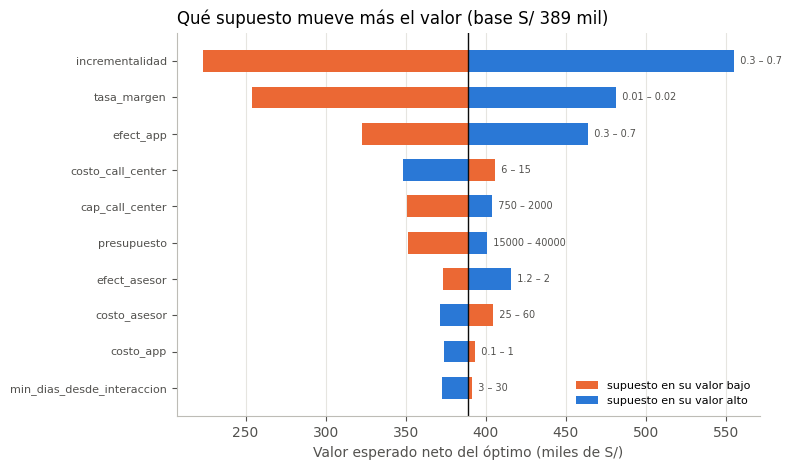

In [7]:
tor = pd.read_csv(C.REPORTS / 'sens_tornado.csv')
fig = S.fig_tornado(tor, C.REPORTS / 'fig' / 'opt_tornado.png')
tor

## 5. Precios sombra

Dual del LP relajado (GLOP) contra diferencias finitas en el LP y en el entero (SCIP).

In [8]:
pd.read_csv(C.REPORTS / 'sens_sombra.csv')

,restriccion,unidad,delta,dual_lp,dif_finita_lp,dif_finita_mip
0,cupo_call_center,S/ por cupo,100,32.85,32.11,32.73
1,cupo_asesor,S/ por cupo,50,-0.00,0.00,0.00
2,presupuesto,S/ por S/ 1.000,1000,3080.39,3037.44,2941.85
3,riesgo_alto,S/ por +1 p.p.,1,NaN,1084.83,1146.79


## 6. Robustez: isotónica vs Platt y semillas

In [9]:
pd.read_csv(C.REPORTS / 'sens_robustez.csv').dropna(axis=1, how='all')

,prueba,variante,brier,logloss,ece,p_min,p_max,ev_optimo,ev_greedy,ev_aleatorio,realizado_optimo,realizado_greedy,realizado_aleatorio,contactados_optimo,jaccard,ev_aleatorio_sd,realizado_aleatorio_sd
0,calibracion,isotonica,0.12727,0.4177,0.0154,0.000,1.000,388855.0,207768.0,113693.0,447275.0,245843.0,124506.0,7020.0,NaN,NaN,NaN
1,calibracion,platt,0.12729,0.4169,0.0196,0.012,0.638,384831.0,202871.0,111088.0,444284.0,244146.0,122995.0,6978.0,NaN,NaN,NaN
2,coincidencia_contactados,isotonica vs platt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.949,NaN,NaN
3,semillas_aleatorio,20 semillas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,111676.0,NaN,NaN,124754.0,NaN,NaN,1801.0,6388.0


## ¿Qué significa para el banco?

Ver la sección final de `reports/optimizacion.md`, que se arma con estas mismas cifras.